# Cookbook 2: Mitra no AutoGluon: Foundation Models In-Context em escala

**Público-alvo:** graduação em Computação / IA. **Pré-requisito:** scikit-learn básico e o cookbook 01.

Este é o par do `01_tabpfn_v2_cookbook.ipynb`. **Mesmos datasets, mesmos splits, mesma baseline, mesmas métricas.** A impressão digital dos splits é comparada no próprio notebook: se os dois divergirem, a célula de conferência falha.

O que muda é o modelo: em vez de usar o `tabpfn` direto, usamos o **AutoGluon** para chamar o **Mitra**, o *foundation model* tabular da Amazon, com pesos abertos (Apache-2.0).

**Ambiente:** roda no Google Colab (CPU ou GPU) ou em Jupyter local. A primeira execução do Mitra baixa os pesos do Hugging Face. O AutoGluon é a instalação mais pesada dos dois notebooks: conte alguns minutos no Colab.

> **Dica de runtime.** O próprio código do AutoGluon avisa que a inferência in-context do Mitra roda de **12 a 63 vezes mais devagar na CPU**. No Colab, troque o runtime para GPU (*Ambiente de execução → Alterar o tipo de ambiente de execução → T4 GPU*) antes de rodar a seção 4: a diferença na coluna `predict_s` é o retrato disso.


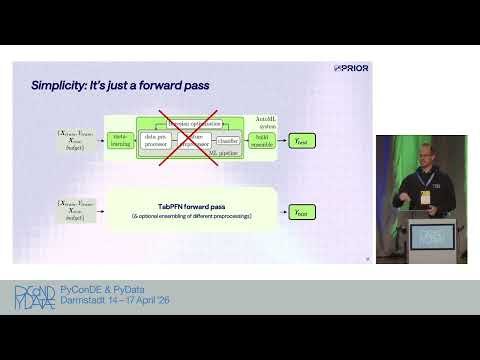

In [1]:
# Vídeo didático: palestra sobre a revolução dos foundation models tabulares
# (Frank Hutter, PyData/PyCon DE 2026), que cobre o AutoGluon e o Mitra no panorama.
from IPython.display import YouTubeVideo

YouTubeVideo("QvU7w_rwXh8", width=700, height=394)


## A transição: do boosting para o *in-context learning* designável

Por cerca de vinte anos o gradient boosting (XGBoost, LightGBM, CatBoost) foi o padrão de fato em dados tabulares, e por um motivo estrutural: features heterogêneas, poucas amostras e sinal concentrado em poucas colunas favorecem árvores, não redes neurais densas (Grinsztajn et al., 2022). O ponto de virada foi o TabPFN, que tratou a tarefa tabular como problema de *in-context learning*: o modelo é pré-treinado em milhões de tarefas sintéticas e, na hora de prever, recebe o conjunto de treino dentro do contexto e devolve a resposta em um *forward pass*, sem gradiente.

Se o modelo não é mais treinado nos seus dados, a pergunta de pesquisa muda de lugar. A arquitetura passa a importar menos, e **o desenho dos dados sintéticos** — o *prior* que gera as tarefas de pré-treinamento — passa a importar mais. É exatamente esse o argumento do **Mitra** (Zhang et al., NeurIPS 2025): em vez de herdar o prior do TabPFN, ele investiga quais propriedades de um *prior* (diversidade, distinção entre tarefas, desempenho medido em dados reais) fazem um *foundation model* generalizar, e treina o modelo numa mistura curada dessas distribuições sintéticas. O resultado é um modelo que supera o TabPFN v2 e o TabICL em classificação e regressão, com melhor eficiência de amostra, mantendo o mesmo teto operacional prático de ~10 000 linhas e 500 features.

Para quem usa, a diferença aparece em três detalhes do código. Primeiro, não existe `TabularPredictor.fit()` treinando pesos: o Mitra é chamado em modo *zero-shot*, com o treino como contexto (`fine_tune=False`); se você quiser adaptar os pesos a um domínio específico, existe o modo de *fine-tuning* (`fine_tune=True` e `fine_tune_steps`), e aí sim há treino. Segundo, o AutoGluon assume a engenharia em volta: tipos de coluna, encoding, validação interna, escolha de metrica e o `leaderboard`. Terceiro, o pacote roda em CPU ou GPU, e aceita valores ausentes e categóricas sem imputação.

O preço tem de ser dito: o *contexto é o modelo*, então o custo de inferência cresce com o tamanho do *support set*, e o desempenho depende de o seu dataset se parecer com a mistura de priors do pré-treinamento. Fora da distribuição, o modelo degrada sem avisar. E, como no notebook 01, o que vem abaixo é **uma única partição de dois datasets pequenos**: mostra o mecanismo, não decide campeonato. Para isso existem TabArena e TabRepo.


## 1. Ambiente

A célula instala o que faltar. O Mitra não vem no `autogluon.tabular` básico: ele está num extra opcional, `autogluon.tabular[mitra]`, que traz `loguru`, `einx`, `omegaconf`, `einops`, `transformers` e `huggingface_hub[torch]` — e que **fixa o PyTorch** em `<2.14`, então num ambiente com torch mais novo o `pip` vai rebaixá-lo. Sem esse extra o comportamento engana: o `fit` não falha no modelo, ele **pula** o Mitra e depois reclama que nenhum modelo foi treinado.


In [2]:
import importlib.util
import subprocess
import sys


def ensure(package: str, import_name: str | None = None) -> None:
    """Install `package` with pip when its module is not importable yet."""
    if importlib.util.find_spec(import_name or package) is None:
        print(f"📦 installing {package} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)


ensure("autogluon.tabular==1.6.3", "autogluon.tabular")  # pinned: the [mitra] extra follows this release

# Mitra lives behind an optional AutoGluon extra, and the failure mode is quiet: without it
# `fit` does not raise on the model, it skips it and then complains that no model was trained
# ("Failed to import Mitra! ... No module named 'omegaconf'").
MITRA_EXTRA_MODULES = ("einx", "omegaconf", "loguru", "einops", "transformers", "huggingface_hub")
missing = [name for name in MITRA_EXTRA_MODULES if importlib.util.find_spec(name) is None]
if missing:
    print(f"📦 installing autogluon.tabular[mitra] (missing: {', '.join(missing)})")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "autogluon.tabular[mitra]==1.6.3"], check=True
    )

print("✅ environment ready")


✅ environment ready


In [3]:
import hashlib
import importlib.metadata
import json
import shutil
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:  # plain Python interpreter
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)

# Experimental protocol shared with 01_tabpfn_v2_cookbook.ipynb.
RANDOM_STATE = 42
TEST_SIZE = 0.25
HOUSING_ROWS = 2500
TARGET = "target"

# Mitra in zero-shot mode: the training rows are the context, no gradient step.
# Switch to {"fine_tune": True, "fine_tune_steps": 10} to adapt the weights instead.
MITRA_HYPERPARAMETERS = {"MITRA": {"fine_tune": False}}

ARTIFACTS = Path("artifacts_mitra")
ARTIFACTS.mkdir(exist_ok=True)
print(f"✅ AutoGluon {importlib.metadata.version('autogluon.tabular')} | Mitra: {MITRA_HYPERPARAMETERS}")


✅ AutoGluon 1.6.3 | Mitra: {'MITRA': {'fine_tune': False}}


## 2. Protocolo experimental comum aos dois cookbooks

Idêntico ao notebook 01, célula por célula. É aqui que a comparação entre os dois cadernos se sustenta: qualquer mudança de seed ou de proporção de teste quebraria a conferência das impressões digitais.


In [4]:
def timeit(fn, *args, **kwargs):
    """Run fn once and return (result, elapsed_seconds)."""
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    return result, time.perf_counter() - start


def fingerprint(*frames) -> str:
    """Order-sensitive hash of the split contents.

    Notebook 02 recomputes the same value and asserts equality: that is how we know the
    two recipes were compared on identical data, and not merely on similar data.
    """
    digest = hashlib.sha256()
    for frame in frames:
        values = np.ascontiguousarray(np.round(frame.to_numpy(dtype=np.float64), 6))
        digest.update(values.tobytes())
    return digest.hexdigest()[:16]


def load_classification_frame() -> pd.DataFrame:
    """Breast cancer: 569 rows, 30 numeric features, binary label in column 'target'."""
    return load_breast_cancer(as_frame=True).frame.rename(columns={"target": TARGET})


def load_regression_frame() -> pd.DataFrame:
    """California housing, subsampled to HOUSING_ROWS rows, label in column 'target'."""
    bunch = fetch_california_housing(as_frame=True)
    return (
        bunch.frame.rename(columns={bunch.target_names[0]: TARGET})
        .sample(n=HOUSING_ROWS, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


def split_frame(frame: pd.DataFrame, stratify: bool = False):
    """One split, one seed, for both cookbooks."""
    label = frame[TARGET]
    train, test = train_test_split(
        frame,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=label if stratify else None,
    )
    return train.reset_index(drop=True), test.reset_index(drop=True)


def feature_matrix(frame: pd.DataFrame) -> np.ndarray:
    return frame.drop(columns=TARGET).to_numpy(dtype=np.float64)


def classification_metrics(model_name, y_true, proba, y_pred, fit_s, predict_s) -> dict:
    """ROC-AUC and macro-F1 plus the wall-clock cost of fit and predict."""
    return {
        "model": model_name,
        "roc_auc": roc_auc_score(y_true, proba),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "fit_s": round(fit_s, 2),
        "predict_s": round(predict_s, 2),
        "total_s": round(fit_s + predict_s, 2),
    }


def regression_metrics(model_name, y_true, y_pred, fit_s, predict_s) -> dict:
    return {
        "model": model_name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "fit_s": round(fit_s, 2),
        "predict_s": round(predict_s, 2),
        "total_s": round(fit_s + predict_s, 2),
    }


RF_KWARGS = {"n_estimators": 300, "n_jobs": -1, "random_state": RANDOM_STATE}

print("✅ helpers ready")


✅ helpers ready


In [5]:
def fresh_dir(name: str) -> Path:
    """Empty directory for a predictor: AutoGluon reuses whatever is already at the path."""
    directory = Path(name)
    shutil.rmtree(directory, ignore_errors=True)
    return directory


def positive_class_proba(predictor: TabularPredictor, data: pd.DataFrame, label) -> np.ndarray:
    """Probability of the positive class; AutoGluon names the columns after the labels."""
    proba = predictor.predict_proba(data)
    column = label if label in proba.columns else proba.columns[-1]
    return proba[column].to_numpy()


print("✅ AutoGluon helpers ready")


✅ AutoGluon helpers ready


In [6]:
train_clf, test_clf = split_frame(load_classification_frame(), stratify=True)

print(f"🔎 breast_cancer: train {train_clf.shape} | test {test_clf.shape}")
print(f"   positive rate: train {train_clf[TARGET].mean():.3f} | test {test_clf[TARGET].mean():.3f}")

clf_fingerprint = fingerprint(train_clf, test_clf)
print(f"🧾 split fingerprint (classification): {clf_fingerprint}")


🔎 breast_cancer: train (426, 31) | test (143, 31)
   positive rate: train 0.627 | test 0.629
🧾 split fingerprint (classification): f04d51ca23b43bbb


In [7]:
train_reg, test_reg = split_frame(load_regression_frame())

print(f"🔎 california_housing: train {train_reg.shape} | test {test_reg.shape}")
print(f"   target: mean {train_reg[TARGET].mean():.3f} | std {train_reg[TARGET].std():.3f}")

reg_fingerprint = fingerprint(train_reg, test_reg)
print(f"🧾 split fingerprint (regression): {reg_fingerprint}")

# Cross-check against notebook 01: same data, or the comparison is meaningless.
reference = Path("splits_fingerprint.json")
if reference.exists():
    expected = json.loads(reference.read_text())
    assert expected["clf"] == clf_fingerprint, "classification split differs from notebook 01"
    assert expected["reg"] == reg_fingerprint, "regression split differs from notebook 01"
    print("✅ splits identical to 01_tabpfn_v2_cookbook.ipynb")
else:
    print("ℹ️ splits_fingerprint.json not found: run notebook 01 first to cross-check.")


🔎 california_housing: train (1875, 9) | test (625, 9)
   target: mean 2.065 | std 1.136
🧾 split fingerprint (regression): 3acefab72a64c343
✅ splits identical to 01_tabpfn_v2_cookbook.ipynb


## 3. Classificação: breast cancer

Mesmas métricas do notebook 01: **ROC-AUC**, **F1-macro** e tempo de parede. A baseline RandomForest é escrita com o mesmo código, para que a única diferença entre os cadernos seja o modelo pré-treinado.

Detalhe do AutoGluon: o `TabularPredictor` **não é** o modelo, é o orquestrador. `label` diz qual coluna prever, `eval_metric` diz o que otimizar na seleção interna e `path` é o diretório em disco onde o predictor é salvo (útil: você pode recarregar com `TabularPredictor.load(path)` sem refazer o fit).

Por padrão o AutoGluon também acrescenta um `WeightedEnsemble_L2` ao portfólio: com um único modelo base, ele apenas repassa a predição do Mitra (compare as duas linhas do `leaderboard` abaixo: mesmo `score_test`, tempo marginal ~0), e é ele que responde ao `predict`. Para medir o Mitra isolado, passe `fit_weighted_ensemble=False` ao `fit`.


In [8]:
# Baseline: Random Forest, the tree-based reference you already know.
rf_clf = RandomForestClassifier(**RF_KWARGS)
_, rf_clf_fit_s = timeit(rf_clf.fit, feature_matrix(train_clf), train_clf[TARGET].to_numpy())
rf_clf_proba, rf_clf_predict_s = timeit(
    lambda: rf_clf.predict_proba(feature_matrix(test_clf))[:, 1]
)

clf_results = [
    classification_metrics(
        "RandomForest (baseline)",
        test_clf[TARGET].to_numpy(),
        rf_clf_proba,
        rf_clf.predict(feature_matrix(test_clf)),
        rf_clf_fit_s,
        rf_clf_predict_s,
    )
]
display(pd.Series(clf_results[-1]))


model        RandomForest (baseline)
roc_auc                     0.994864
f1_macro                     0.95467
fit_s                           0.46
predict_s                       0.06
total_s                         0.52
dtype: object

In [9]:
def warm_up_mitra_classifier() -> None:
    """First fit downloads the Mitra checkpoint: keep that out of the measured fit."""
    warm = TabularPredictor(
        label=TARGET, eval_metric="roc_auc", path=fresh_dir("ag_warmup_clf"), verbosity=0
    )
    warm.fit(train_clf.head(128), hyperparameters=MITRA_HYPERPARAMETERS)


print("🔥 warm-up (downloads the Mitra classifier weights)")
warm_up_mitra_classifier()

# TabularPredictor with a single model in the portfolio: Mitra, zero-shot.
mitra_clf = TabularPredictor(
    label=TARGET, eval_metric="roc_auc", path=fresh_dir("ag_mitra_clf"), verbosity=2
)
_, mitra_clf_fit_s = timeit(
    mitra_clf.fit, train_clf, hyperparameters=MITRA_HYPERPARAMETERS
)

positive_label = sorted(test_clf[TARGET].unique())[-1]
mitra_clf_proba, mitra_clf_predict_s = timeit(
    positive_class_proba, mitra_clf, test_clf, positive_label
)
mitra_clf_pred = mitra_clf.predict(test_clf).to_numpy()

clf_results.append(
    classification_metrics(
        "Mitra / AutoGluon",
        test_clf[TARGET].to_numpy(),
        mitra_clf_proba,
        mitra_clf_pred,
        mitra_clf_fit_s,
        mitra_clf_predict_s,
    )
)
display(pd.Series(clf_results[-1]))


🔥 warm-up (downloads the Mitra classifier weights)


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Verbosity: 2 (Standard Logging)


...

AutoGluon training complete, total runtime = 183.7s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 0.8 rows/s (86 batch size)


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/fabricio/.hermes/cache/scratch/tfm-cookbook/ag_mitra_clf")


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


model        Mitra / AutoGluon
roc_auc               0.998532
f1_macro              0.970246
fit_s                   183.29
predict_s               160.22
total_s                 343.51
dtype: object

In [10]:
clf_table = (
    pd.DataFrame(clf_results).set_index("model").sort_values("roc_auc", ascending=False)
)
clf_table.to_csv(ARTIFACTS / "results_classification.csv")
print("📊 Classification: breast cancer (426 train / 143 test)")
display(clf_table.round(4))

# AutoGluon's own report for the fitted model (fit_time is measured by AutoGluon itself).
display(mitra_clf.leaderboard(test_clf, silent=True))


📊 Classification: breast cancer (426 train / 143 test)


,roc_auc,f1_macro,fit_s,predict_s,total_s
model,,,,,
Mitra / AutoGluon,0.9985,0.9702,183.29,160.22,343.51
RandomForest (baseline),0.9949,0.9547,0.46,0.06,0.52


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,Mitra,0.998532,1.0,roc_auc,133.159055,101.718853,81.528068,133.159055,101.718853,81.528068,1,True,1
1,WeightedEnsemble_L2,0.998532,1.0,roc_auc,133.178484,101.719780,81.532449,0.019429,0.000927,0.004381,2,True,2


## 4. Regressão: California housing (2500 linhas)

Mesmo recorte do notebook 01: 1875 linhas de treino, 625 de teste, `random_state=42`. Métricas: **RMSE**, **MAE** e **R²**.

Repare que o `eval_metric` do predictor muda junto com a tarefa: aqui usamos `root_mean_squared_error`. O `eval_metric` não muda o resultado do Mitra em modo zero-shot (não há otimização sobre os seus dados), mas muda a validação interna do AutoGluon e o `leaderboard`.


In [11]:
rf_reg = RandomForestRegressor(**RF_KWARGS)
_, rf_reg_fit_s = timeit(rf_reg.fit, feature_matrix(train_reg), train_reg[TARGET].to_numpy())
rf_reg_pred, rf_reg_predict_s = timeit(rf_reg.predict, feature_matrix(test_reg))

reg_results = [
    regression_metrics(
        "RandomForest (baseline)",
        test_reg[TARGET].to_numpy(),
        rf_reg_pred,
        rf_reg_fit_s,
        rf_reg_predict_s,
    )
]
display(pd.Series(reg_results[-1]))


model        RandomForest (baseline)
rmse                        0.582245
mae                         0.389812
r2                          0.739367
fit_s                           1.12
predict_s                       0.16
total_s                         1.28
dtype: object

In [12]:
def warm_up_mitra_regressor() -> None:
    warm = TabularPredictor(
        label=TARGET,
        eval_metric="root_mean_squared_error",
        path=fresh_dir("ag_warmup_reg"),
        verbosity=0,
    )
    warm.fit(train_reg.head(128), hyperparameters=MITRA_HYPERPARAMETERS)


print("🔥 warm-up (downloads the Mitra regressor weights)")
warm_up_mitra_regressor()

mitra_reg = TabularPredictor(
    label=TARGET,
    eval_metric="root_mean_squared_error",
    path=fresh_dir("ag_mitra_reg"),
    verbosity=2,
)
_, mitra_reg_fit_s = timeit(mitra_reg.fit, train_reg, hyperparameters=MITRA_HYPERPARAMETERS)
mitra_reg_pred, mitra_reg_predict_s = timeit(mitra_reg.predict, test_reg)

reg_results.append(
    regression_metrics(
        "Mitra / AutoGluon",
        test_reg[TARGET].to_numpy(),
        np.asarray(mitra_reg_pred),
        mitra_reg_fit_s,
        mitra_reg_predict_s,
    )
)
display(pd.Series(reg_results[-1]))


🔥 warm-up (downloads the Mitra regressor weights)


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Verbosity: 2 (Standard Logging)


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 18 21:54:43 UTC 2026
CPU Count:          12
Pytorch Version:    2.13.0+cu130
CUDA Version:       CUDA is not available
Memory Avail:       14.31 GB / 19.53 GB (73.3%)
Disk Space Avail:   857.96 GB / 1006.85 GB (85.2%)


...

	0.0s	 = Validation runtime


AutoGluon training complete, total runtime = 326.99s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 2.3 rows/s (375 batch size)


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/home/fabricio/.hermes/cache/scratch/tfm-cookbook/ag_mitra_reg")


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


model        Mitra / AutoGluon
rmse                  0.511521
mae                   0.349252
r2                    0.798839
fit_s                   326.03
predict_s               177.36
total_s                 503.39
dtype: object

In [13]:
reg_table = (
    pd.DataFrame(reg_results).set_index("model").sort_values("rmse", ascending=True)
)
reg_table.to_csv(ARTIFACTS / "results_regression.csv")
print("📊 Regression: california_housing, 2500 rows sampled (1875 train / 625 test)")
display(reg_table.round(4))

display(mitra_reg.leaderboard(test_reg, silent=True))


📊 Regression: california_housing, 2500 rows sampled (1875 train / 625 test)


,rmse,mae,r2,fit_s,predict_s,total_s
model,,,,,,
Mitra / AutoGluon,0.5115,0.3493,0.7988,326.03,177.36,503.39
RandomForest (baseline),0.5822,0.3898,0.7394,1.12,0.16,1.28


/home/fabricio/.hermes/cache/scratch/tfm-cookbook/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,Mitra,-0.511521,-0.569103,root_mean_squared_error,199.765743,163.859917,162.671137,199.765743,163.859917,162.671137,1,True,1
1,WeightedEnsemble_L2,-0.511521,-0.569103,root_mean_squared_error,199.771198,163.860255,162.675510,0.005454,0.000339,0.004373,2,True,2


## 5. Como ler o que você acabou de ver

Junte as duas colunas de tempo com a história que cada modelo conta. No RandomForest, `fit` **aprende** com os dados; no Mitra, `fit` só monta o contexto — o número relevante é o tempo total, que já inclui o custo de carregar o *checkpoint* (deixado fora da medição pelo warm-up). Em contrapartida, cada `predict` do Mitra reencena o *support set* inteiro dentro da atenção: o custo cresce com o número de linhas de treino, não com o número de linhas a prever. Em produção isso se resolve com cache de contexto e um `predictor` residente em memória (`TabularPredictor.load(path)`), não recarregando o modelo a cada chamada.

Compare com o notebook 01. Lá o TabPFN v2 e o Mitra competem em condição equivalente: mesmo split, mesma baseline, mesmas métricas. Qualquer diferença entre os dois cadernos vem do modelo, não do experimento — e é isso que a conferência de impressão digital garante.

Uma advertência que o seu próprio run pode trazer: nesta execução em CPU, o Mitra ficou **atrás** do TabPFN v2 na regressão, o oposto do ranking agregado dos papers. Isso não é bug nem contradição: os papers reportam média sobre centenas de datasets com orçamento de tuning, e com um único split de um dataset pequeno o *support set* específico pesa mais que a diferença entre os modelos. Compare os números da **sua** execução, não os de um texto.

O que **não** se pode concluir: vencedor. Com uma partição e dois datasets pequenos você mede ordem de grandeza e comportamento, não significância. Para afirmar superioridade, repita com várias sementes, reporte média e desvio, inclua um GBDT bem ajustado (LightGBM/CatBoost) e olhe benchmarks com centenas de datasets — TabArena, TabRepo, AMLB. Vale lembrar também o limite operacional: acima de ~10 000 linhas e 500 features o auto-detect do AutoGluon **pula** o Mitra em vez de tentar ajustá-lo, e o predictor cai nos modelos clássicos do portfólio. Foundation model tabular não é resposta universal; é mais um modelo no time, escolhido pelo tamanho e pela forma do seu dado.

### Referências

**Mitra (modelo deste notebook)**
Zhang, X., Maddix, D. C., Yin, J., Erickson, N., Ansari, A. F., Han, B., Zhang, S., Akoglu, L., Faloutsos, C., Mahoney, M. W., Hu, C., Rangwala, H., Karypis, G., & Wang, B. (2025). *Mitra: Mixed Synthetic Priors for Enhancing Tabular Foundation Models.* NeurIPS 2025. arXiv:2510.21204.

**AutoGluon (o orquestrador)**
Erickson, N., Mueller, J., Shirkov, A., Zhang, H., Larroy, P., Li, M., & Smola, A. (2020). *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data.* arXiv:2003.06505.

**TabPFN (o modelo do notebook 01, e o ponto de partida do argumento do Mitra)**
Hollmann, N., Müller, S., Purucker, L., Krishnakumar, A., Körfer, M., Hoo, S. B., Schirrmeister, R. T., & Hutter, F. (2025). *Accurate predictions on small data with a tabular foundation model.* **Nature** 637, 319–326. DOI: 10.1038/s41586-024-08328-6. Preprint: arXiv:2402.12884.

**Por que o boosting dominou e o que mudou**
Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why do tree-based models still outperform deep learning on typical tabular data?* NeurIPS 2022, Datasets and Benchmarks Track. arXiv:2207.08815.

**Documentação, código e pesos**
AutoGluon, foundation models: https://auto.gluon.ai/stable/tutorials/tabular/tabular-foundational-models.html · Mitra classifier: https://huggingface.co/autogluon/mitra-classifier · Mitra regressor: https://huggingface.co/autogluon/mitra-regressor

```bibtex
@inproceedings{zhang2025mitra,
  title     = {Mitra: Mixed Synthetic Priors for Enhancing Tabular Foundation Models},
  author    = {Zhang, Xiyuan and Maddix, Danielle C. and Yin, Junming and Erickson, Nick and
               Ansari, Abdul Fatir and Han, Boran and Zhang, Shuai and Akoglu, Leman and
               Faloutsos, Christos and Mahoney, Michael W. and Hu, Cuixiong and
               Rangwala, Huzefa and Karypis, George and Wang, Bernie},
  booktitle = {Advances in Neural Information Processing Systems (NeurIPS)},
  year      = {2025},
  eprint    = {2510.21204},
  archivePrefix = {arXiv}
}

@article{erickson2020autogluon,
  title   = {AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data},
  author  = {Erickson, Nick and Mueller, Jonas and Shirkov, Alexander and Zhang, Hang and
             Larroy, Pedro and Li, Mu and Smola, Alex},
  journal = {arXiv preprint arXiv:2003.06505},
  year    = {2020}
}

@article{hollmann2025tabpfn,
  title   = {Accurate predictions on small data with a tabular foundation model},
  author  = {Hollmann, Noah and M{\"u}ller, Samuel and Purucker, Lennart and
             Krishnakumar, Arjun and K{\"o}rfer, Max and Hoo, Shi Bin and
             Schirrmeister, Robin Tibor and Hutter, Frank},
  journal = {Nature},
  volume  = {637},
  pages   = {319--326},
  year    = {2025},
  doi     = {10.1038/s41586-024-08328-6}
}

@inproceedings{grinsztajn2022trees,
  title     = {Why do tree-based models still outperform deep learning on typical tabular data?},
  author    = {Grinsztajn, L{\'e}o and Oyallon, Edouard and Varoquaux, Ga{\"e}l},
  booktitle = {Advances in Neural Information Processing Systems (NeurIPS), Datasets and Benchmarks Track},
  year      = {2022},
  eprint    = {2207.08815},
  archivePrefix = {arXiv}
}
```

**Próximo passo:** ative o modo de fine-tuning, como na documentação do AutoGluon (`{"MITRA": {"fine_tune": True, "fine_tune_steps": 10}}`), e compare com o zero-shot. Adaptar os pesos é o passo que transforma o modelo genérico em modelo do seu domínio. Vale saber que, sem `fine_tune` explícito, o AutoGluon assume `True` e cai no fine-tuning (avisando que é lento em CPU); nós passamos `False` para deixar claro que o modelo está em modo *zero-shot*.
